# TD2 Victor Bouvier d'Acher

In [1]:
from skimage import data, color, filters, util, measure
from skimage.color import label2rgb, rgb2gray
from skimage.util import random_noise
from skimage.filters import sobel, gaussian, threshold_otsu
from skimage.restoration import inpaint, denoise_tv_chambolle, denoise_bilateral
from skimage.morphology import disk
from skimage.segmentation import slic
from pykuwahara import kuwahara
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
from scipy.ndimage import binary_dilation

In [2]:
def show_image(image, title='Image', cmap_type= 'gray'):
    plt.imshow(image, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [3]:
def plot_comparison(original, modified, title_original,title_modified):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 6),
    sharex=True,sharey=True)
    ax1.imshow(original ,cmap = 'viridis')
    ax1.set_title(title_original)
    ax1.axis('off')
    ax2.imshow(modified, cmap = 'gray')
    ax2.set_title(title_modified)
    ax2.axis('off')

In [4]:
def show_image_contour(image, contours):
    plt.figure()
    for n, contour in enumerate(contours):
        plt.plot(contour[:, 1], contour[:, 0], linewidth=3)
    plt.imshow(image, interpolation='nearest', cmap='gray_r')
    plt.title('Contours')
    plt.axis('off')

In [5]:
def get_mask(image):
    # Create mask with six block defect regions
    mask = np.zeros(image.shape[:-1], dtype=bool)
    mask[20:60, 0:20] = 1
    mask[160:180, 70:155] = 1
    mask[30:60, 170:195] = 1
    mask[-60:-30, 170:195] = 1
    mask[-180:-160, 70:155] = 1
    mask[-60:-20, 0:20] = 1

    # add a few long, narrow defects
    mask[200:205, -200:] = 1
    mask[150:255, 20:23] = 1
    mask[365:368, 60:130] = 1

    # add randomly positioned small point-like defects
    rstate = np.random.default_rng(0)
    for radius in [0, 2, 4]:
        # larger defects are less common
        thresh = 3 + 0.25 * radius  # make larger defects less commmon
        tmp_mask = rstate.standard_normal(image.shape[:-1]) > thresh
        if radius > 0:
            tmp_mask = binary_dilation(tmp_mask, disk(radius, dtype=bool))
        mask[tmp_mask] = 1
    return mask

1. Exercice 

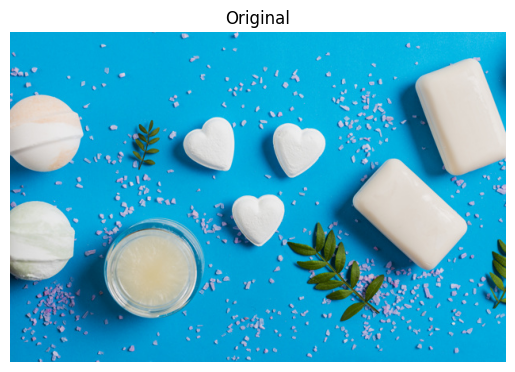

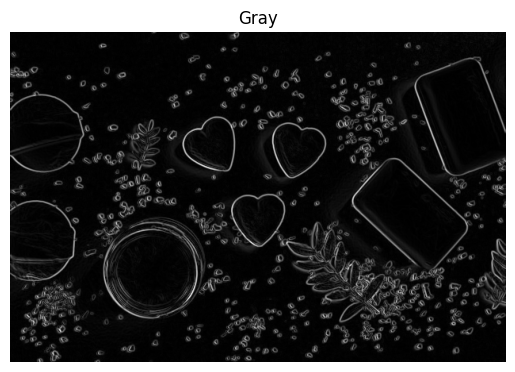

In [6]:
soaps_image = mpimg.imread('soap_image.jpg')


soaps_image_gray = color.rgb2gray(soaps_image)
dete = sobel(soaps_image_gray)


show_image(soaps_image, "Original")
show_image(dete, "Gray")


2. Exercice

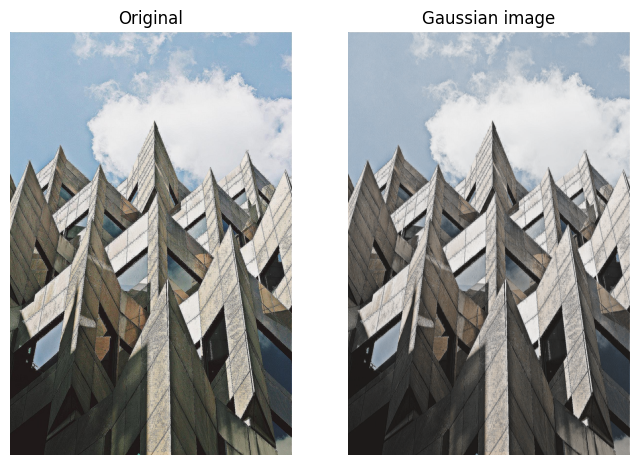

In [7]:
building_image = mpimg.imread('building_image.jpg')

gaussian_image = gaussian(building_image, channel_axis=True)

plot_comparison(building_image, gaussian_image, "Original", "Gaussian image")

3. Exercice

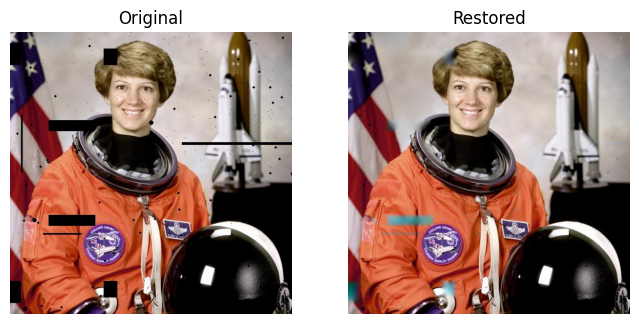

In [8]:
astronaut = mpimg.imread('astronaut.jpg')

mask = get_mask(astronaut)

restored_image = inpaint.inpaint_biharmonic(astronaut, mask, channel_axis=-1)

plot_comparison(astronaut, restored_image, "Original", "Restored")

4. Exercice

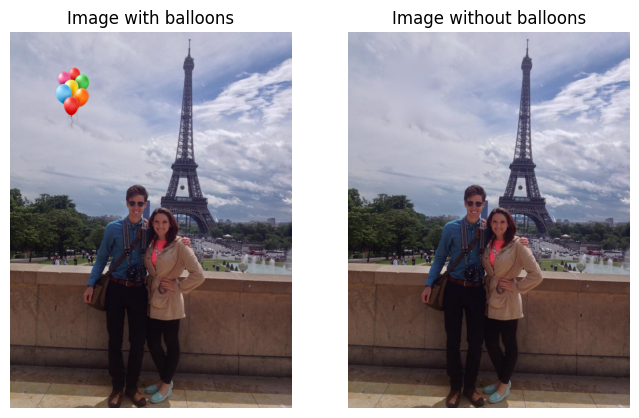

In [9]:
image_with_balloons = mpimg.imread('tour.jpg')

mask = np.zeros(image_with_balloons.shape[:-1], dtype=bool)

mask[50:240, 100:220 ] = 1

image_without_balloons = inpaint.inpaint_biharmonic(image_with_balloons, mask, channel_axis=-1)

plot_comparison(image_with_balloons,image_without_balloons , 'Image with balloons' , 'Image without balloons')

5. Exercice

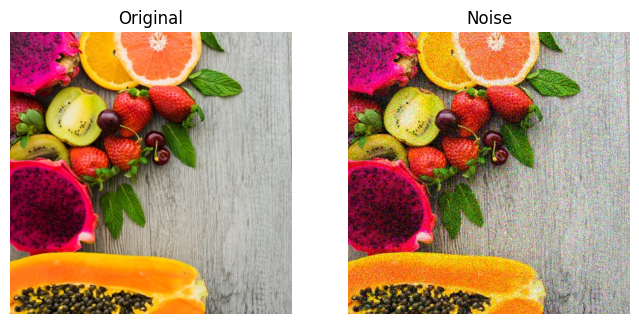

In [10]:
fruit_image = mpimg.imread('fruits_square.jpg')

noise = random_noise(fruit_image)

plot_comparison(fruit_image, noise, "Original", "Noise")

6. Exercice

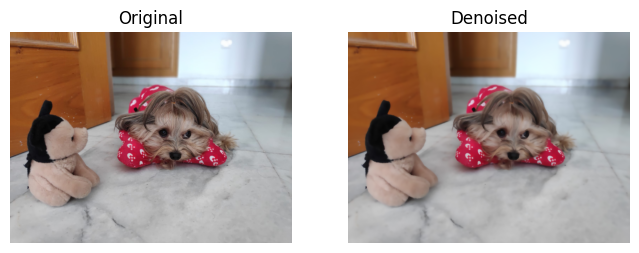

In [11]:
dog = mpimg.imread('miny.jpeg')

denoised = denoise_tv_chambolle(dog, weight=0.1, channel_axis=-1)

plot_comparison(dog, denoised, "Original", "Denoised")

7. Exercice

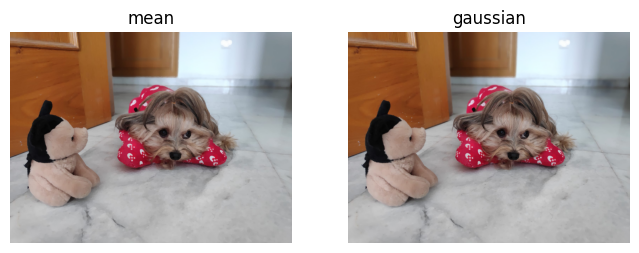

In [12]:
filt1 = kuwahara(dog, method='mean', radius=3)
filt2 = kuwahara(dog, method='gaussian', radius=3)    

plot_comparison(filt1, filt2 ,'mean', 'gaussian')

8. Exercice

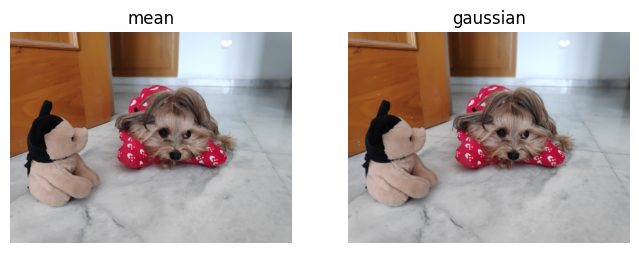

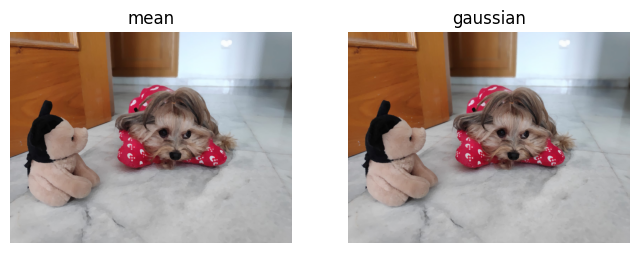

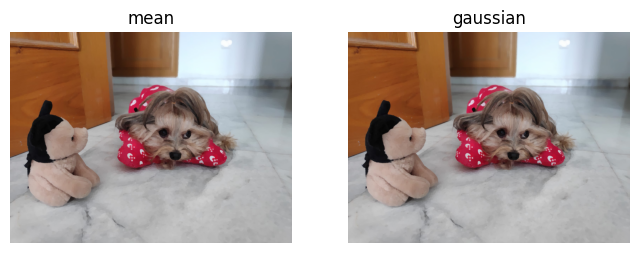

In [13]:
filt1 = kuwahara(dog, method='mean', radius=4)

for i in range(1, 4, 1):
    filt2 = kuwahara(dog, method='gaussian', radius=4, sigma=i)

    plot_comparison(filt1, filt2 ,'mean', 'gaussian')

9. Exercice

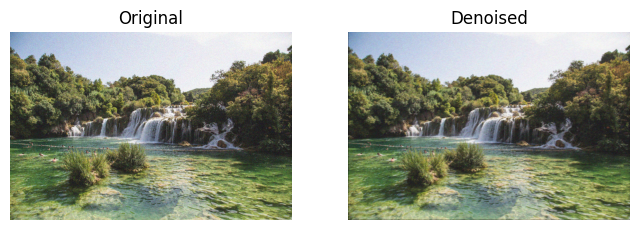

In [14]:
nature = mpimg.imread('noise-noisy-nature.jpg')

denoise = denoise_bilateral(nature, channel_axis=-1)

plot_comparison(nature, denoise, "Original", "Denoised")

10. Exercice

In [15]:
chinoise = mpimg.imread('chinese.jpg')

print(np.shape(chinoise))

(265, 191, 3)


12. Exercice

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


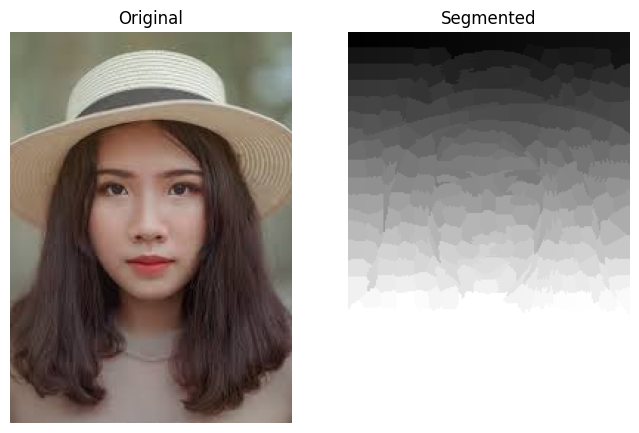

In [16]:
segments = slic(chinoise, n_segments=400)

segmented_image = label2rgb(segments, segments, kind='avg')

plot_comparison(chinoise, segmented_image, "Original", "Segmented")

13. Exercice

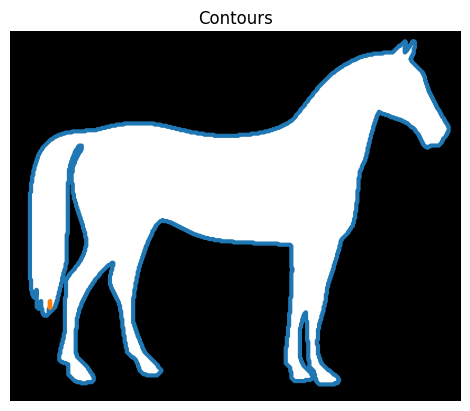

In [17]:
cheval = data.horse()

# thresh = threshold_otsu(cheval)

# thresholded = cheval > thresh

contours = measure.find_contours(cheval, 0.8)

show_image_contour(cheval, contours)

14. Exercice

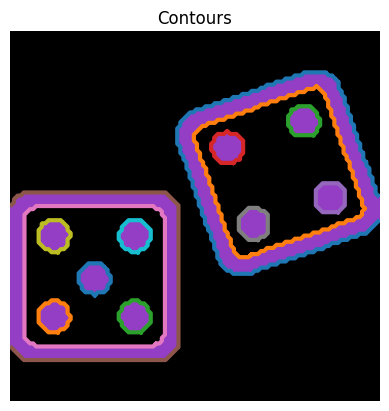

In [18]:
de = mpimg.imread('dices.png')[:,:,:3]

gris = rgb2gray(de)

thresh = threshold_otsu(gris)

thresholded = gris > thresh

contour = measure.find_contours(thresholded, 0.8)

show_image_contour(de, contour)

15. Exercice

Dice's dots number: 9. 


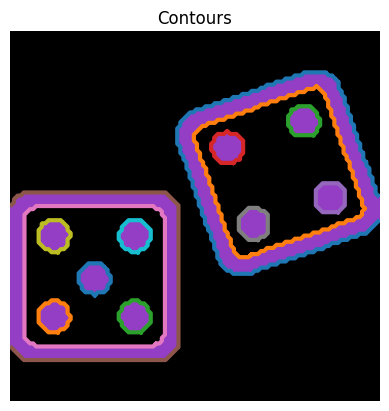

In [19]:
shape_contours = [cnt.shape[0] for cnt in contour]

max_dots_shape = 50

dots_contours = [cnt for cnt in contour if np.shape(cnt)[0] < max_dots_shape]

show_image_contour(de, contour)

print("Dice's dots number: {}. ".format(len(dots_contours)))
